In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import SimpleRNN, Dense

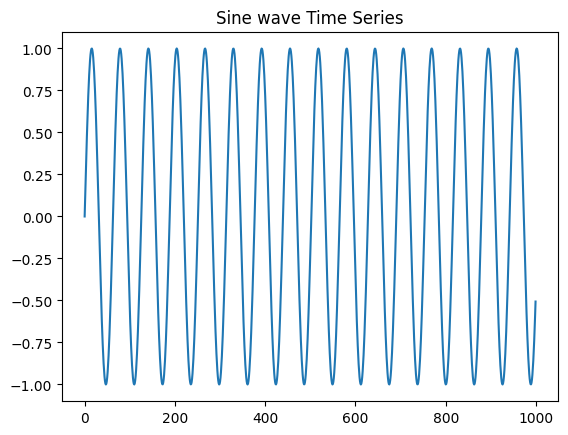

In [3]:
t = np.linspace(0,100,1000)
data = np.sin(t)

plt.plot(data)
plt.title('Sine wave Time Series')
plt.show()

In [4]:
len(data)

1000

In [5]:
# Create Sequence (Sliding window)
window_size=20

X=[]
y=[]

for i in range(len(data)-window_size):
    X.append(data[i:i+window_size])
    y.append(data[i+window_size])
X = np.array(X)
y = np.array(y)

In [6]:
X = X.reshape((X.shape[0],X.shape[1],1)) #(No. of seq, seqence_len, No. of features per time)

In [7]:
X.shape

(980, 20, 1)

In [ ]:
#train test split
split = int(0.8*len(X))

X_train,X_test = X[:split],X[split:]
y_train,y_test = y[:split],y[split:]

In [9]:
# Build model

model = Sequential([
    SimpleRNN(32,input_shape=(window_size,1)),
    Dense(1)
])

c:\Users\MINA\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(optimizer='adam',loss='mse')

In [11]:
model.fit(
    X_train,y_train,
          epochs=20,
          batch_size=32,
          validation_data=(X_test,y_test
        ))

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0865 - val_loss: 0.0127
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0077 - val_loss: 0.0039
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024 - val_loss: 0.0011
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.4112e-04 - val_loss: 5.5083e-04
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.0042e-04 - val_loss: 3.9714e-04
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.4496e-04 - val_loss: 3.2071e-04
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.5117e-04 - val_loss: 2.2429e-04
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8064e-04 - val_loss: 1.4072e-04
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2286e-04 - val_loss: 1.0295e-04
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.8848e-05 - val_loss: 7.3850e-05
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.5295e-05 - val_loss: 6.0435e-05
Epoch 12/

In [12]:
predictions = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


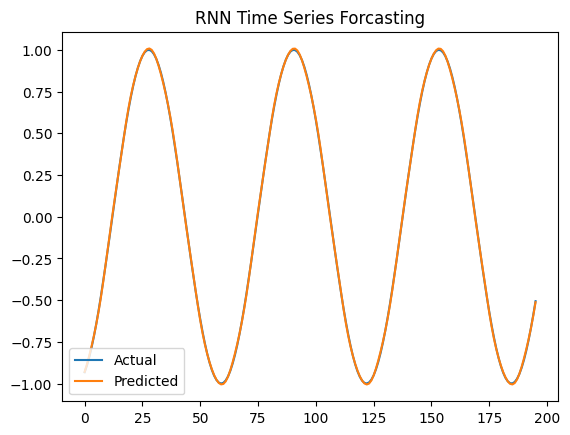

In [16]:
plt.plot(y_test,label='Actual')
plt.plot(predictions,label='Predicted')
plt.legend()
plt.title('RNN Time Series Forcasting')
plt.show()

In [15]:
last_seq = X_test[-1].reshape(1,window_size,1)
next_value = model.predict(last_seq)
print('Next predicted value:',next_value)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Next predicted value: [[-0.51266426]]
